# Descriptive statistics about ESCO and O*NET skills and occupations
Felix Zaussinger | 06.04.2022

## Core Analysis Goal(s)
1. Find out how green & brown skills/tasks are distributed across occupations:
- What are the greenest/brownest occupations according to ESCO? Do they make any sense?
- What are the greenest occupations according to O*NET? How do they compare with
those in ESCO?
- How well do the greenness scores correlate?
- Does differentiating essential & optional ESCO skills make a big or marginal
difference?
2. What tasks/skills are important for the greennest/brownest occupations? How do
they compare between ESCO & O*NET?
3.

## Key Insight(s)
1.
2.
3.

In [21]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, stats_utils, plotting_utils
from src.data.esco import EscoDs
import mapping_career_causeways

plt.style.use({'figure.facecolor': 'white'})

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set(rc={'figure.figsize': (5, 5.), 'figure.facecolor': 'white'})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths(fn_config_path="paths_config.yml")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Configuration files

In [2]:
fn_config_path = "paths_config.yml"
fn_config_data = "data_config.yml"
fn_config_model = "model_config.yml"
fn_config_vis = "vis_config.yml"

## 1. Inspection of ESCO data

In [3]:
esco = EscoDs(fn_config_path=fn_config_path, fn_config_data=fn_config_data)

### 1.1 ESCO Skills Pillar

In [4]:
skills_data = esco.skills_metadata()
skills_data

INFO:src.data.esco:Calculating & merging ESCO occupation metadata (green labels, coreness).


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,broaderConceptPT,broaderConceptUri,skill_green,skill_brown,machineScore,skill_neutral,skillClassification,coreness
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of mu...,NaN,released,2016-12-20T17:43:43Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...,NaN,NaN,False,False,NaN,True,neutral,0.002187
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional...,NaN,released,2016-12-20T20:17:49Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Supervise the operations of a correctional fac...,NaN,NaN,False,False,NaN,True,neutral,0.000000
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-...,NaN,released,2016-12-20T19:18:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c...",NaN,NaN,False,False,NaN,True,neutral,0.000748
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...,NaN,released,2016-12-20T20:02:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ...",NaN,NaN,False,False,NaN,True,neutral,0.049473
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,establish available services\ndetermine rehabi...,NaN,released,2016-12-20T20:15:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Identify the different services available for ...,NaN,NaN,False,False,NaN,True,neutral,0.001577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13886,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/ffef5eb3-a15e...,skill/competence,sector-specific,remediate healthcare user's occupational perfo...,restore healthcare user's occupational perform...,NaN,released,2016-12-20T19:25:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Remediate or restore the cognitive, sensorimot...",NaN,NaN,False,False,NaN,True,neutral,0.000103
13887,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0b074-5a76...,skill/competence,sector-specific,install transport equipment lighting,install transport equipment illumination\nfix ...,NaN,released,2016-12-20T20:03:21Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Install lighting elements in transport equipme...,NaN,NaN,False,False,NaN,True,neutral,0.013943
13888,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0e2cd-d0bd...,knowledge,sector-specific,natural language processing,NLP,NaN,released,2016-08-04T15:19:37Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,The technologies which enable ICT devices to u...,NaN,NaN,False,False,NaN,True,neutral,0.025162
13889,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff5bc45-b506...,skill/competence,cross-sector,coordinate construction activities,reviewing construction progress\nconstruction ...,NaN,released,2016-12-20T18:22:35Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Coordinate the activities of several construct...,NaN,NaN,False,False,NaN,True,neutral,0.065232


#### Green, brown and neutral skills

Number and share of skills by GBN classification

In [5]:
skill_cols = ["skill_green", "skill_brown", "skill_neutral"]

n_skills_by_gbn = skills_data[skill_cols].sum().to_frame("n")
n_skills_by_gbn.loc[:, "share"] = n_skills_by_gbn / len(skills_data)
n_skills_by_gbn

,n,share
skill_green,570,0.041034
skill_brown,477,0.034339
skill_neutral,12844,0.924627


#### Skill type
- knowledge: body of facts, principles theories and practices related to a
field/work/study
- skills: ability to apply knowledge to complete tasks
- competence: proven ability to use knowledge and skills

In [6]:
skills_data.skillType.unique()

array(['skill/competence', 'knowledge', nan], dtype=object)

Q1: How are g/b/n skills distributed across skill types?

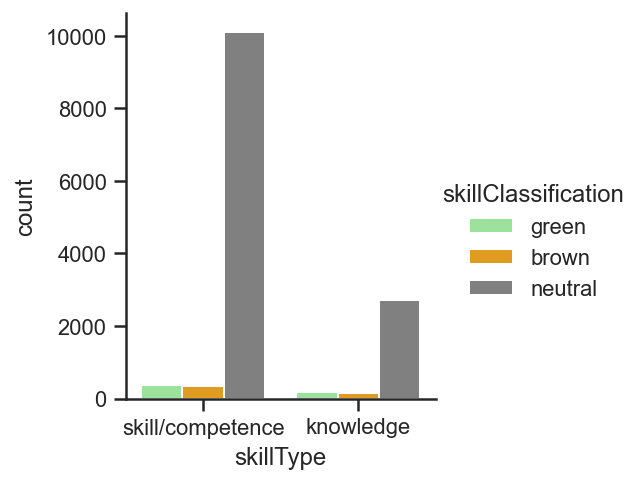

In [22]:
sns.catplot(
    data=skills_data,
    kind="count",
    x="skillType",
    hue="skillClassification",
    height=3.5,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
)

plt.show()

In [8]:
skills_data.groupby("skillType").sum()

,skill_green,skill_brown,machineScore,skill_neutral,coreness
skillType,,,,,
knowledge,186,141,110.310344,2730,90.749882
skill/competence,384,336,240.234480,10113,190.050483


#### Reuse level

The ESCO reuse level can be used to derive:
- how transversal a skill is
- a rough differentiation between skills and tasks

Skills probably correspond to cross-sector & transversal and tasks to sector-specific
and occupation-specific.

In [9]:
skills_data.reuseLevel.unique()

array(['sector-specific', 'occupation-specific', 'cross-sector',
       'transversal'], dtype=object)

Q: How are g/b/n skills distributed across reuse levels?

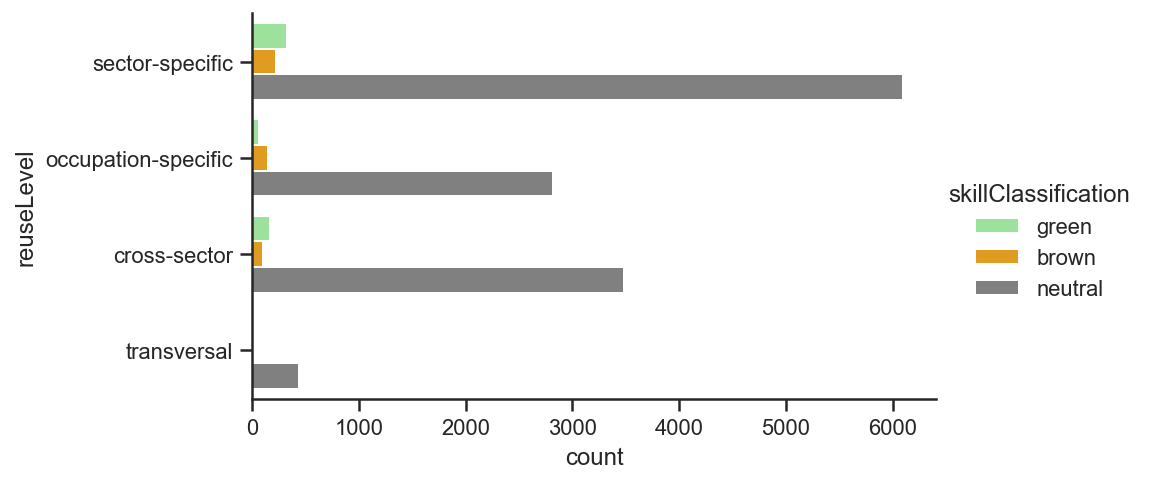

In [10]:
sns.catplot(
    data=skills_data,
    kind="count",
    y="reuseLevel",
    hue="skillClassification",
    height=3.5,
    aspect=2,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
    orient="v"
)

Answer: green skills may be more transversal and thus enable smoother job
transitions.
- green skills more sector-specific and cross-sectoral
- brown skills more occupation-specific

Q: Are green skills more central/core than brown or neutral skills?

In [11]:
# drop nans
skills_data_clean = skills_data.dropna(subset=["coreness"])
len(skills_data_clean)

13379

In [12]:
df_pbsr = stats_utils.pbsr(skills_data_clean, "coreness", skill_cols)
df_pbsr

,pbsr,pval
skill_green,0.052720,1.049824e-09
skill_brown,-0.042455,8.996940e-07
skill_neutral,-0.005557,5.204347e-01


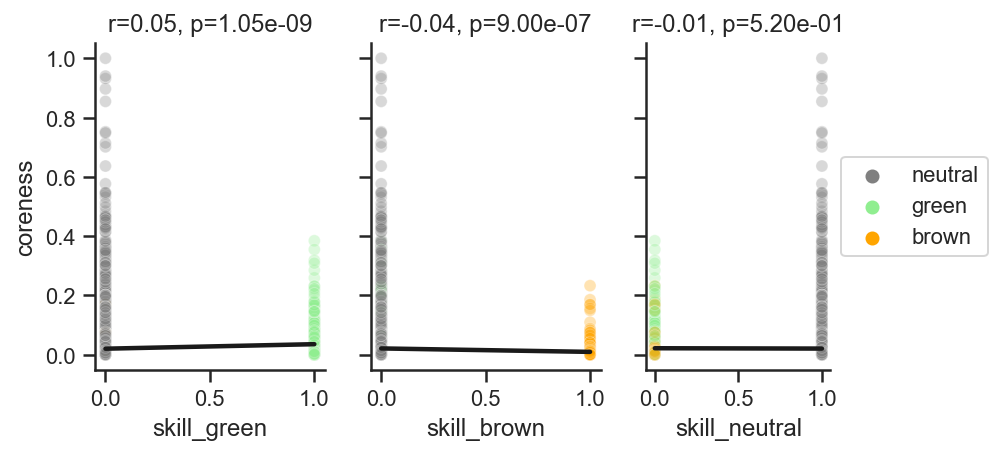

In [13]:
f, axes = plt.subplots(1, 3, sharey=True, sharex=True, figsize=(7, 3))

for i, xvar in enumerate(skill_cols):

    pbsr = df_pbsr.loc[xvar, :]
    r = pbsr.loc["pbsr"]
    pval = pbsr.loc["pval"]

    sns.scatterplot(
        data=skills_data_clean,
        x=xvar,
        y="coreness",
        hue="skillClassification",
        hue_order=["neutral", "green", "brown"],
        palette=["grey", "lightgreen", "orange"],
        alpha=0.3,
        ax=axes[i],
        legend=True if i == len(skill_cols) - 1 else False
    )

    sns.regplot(
        data=skills_data_clean,
        x=xvar,
        y="coreness",
        scatter=False,
        color="k",
        ax=axes[i],
    )

    axes[i].set_title("r={:.2f}, p={:.2e}".format(r, pval))

    if i == len(skill_cols) - 1:
        plotting_utils.move_legend_to_right(axes[i])

sns.despine()

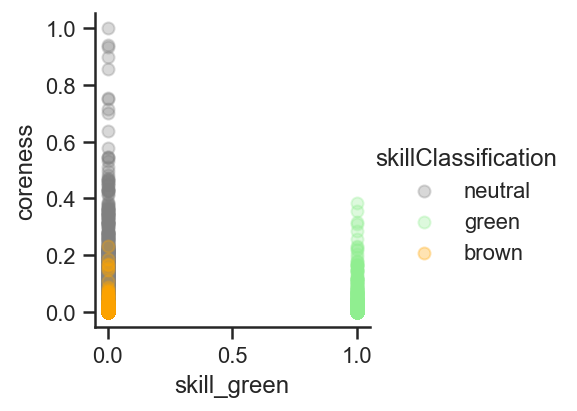

In [14]:
sns.lmplot(
    data=skills_data_clean,
    x="skill_green",
    y="coreness",
    hue="skillClassification",
    fit_reg=True,
    ci=None,
    hue_order=["neutral", "green", "brown"],
    palette=["grey", "lightgreen", "orange"],
    height=3,
    scatter_kws={"alpha": 0.3}
)

A: Green skills are more central/core than brown skills.

- *green* skills are weakly yet significantly *positively* correlated with skills
coreness
- *brown* skills are weakly yet significantly *negatively* correlated with skills
coreness
- *neutral* skills are *not significantly correlated* with skills coreness at p < 0.05

### 1.2 ESCO Occupations Pillar

Read matched occupation metadata

In [105]:
occ_data_with_duplicates = esco.occupation_metadata()

Read occupation-skills and occupation-similarity matrices

In [106]:
osms = esco.occupation_skills_matrix()
osm_weighted = osms["osm_weighted"]
osm_unweighted = osms["osm_unweighted"]

INFO:src.data.esco:Creating occupation-skills matrix.


**!!! 27 duplicated occupations in occupation_metadata. merging steps need a revision!**

In [107]:
len(occ_data_with_duplicates) - occ_data_with_duplicates.conceptUri.duplicated().sum()

3008

Check if index matches with OSM index

In [108]:
assert (occ_data_with_duplicates.loc[~occ_data_with_duplicates.conceptUri.duplicated(), "conceptUri"] == osm_weighted
    .index)\
    .all()

In [109]:
occ_data = occ_data_with_duplicates.loc[~occ_data_with_duplicates.conceptUri.duplicated()].reset_index(drop=True)

**Q: What are the greenest/brownest occupations according to the ESCO GBN labels?**

In [110]:
occ_data.columns

Index(['conceptType', 'conceptUri', 'iscoGroup', 'preferredLabel', 'altLabels',
       'hiddenLabels', 'status', 'modifiedDate', 'regulatedProfessionNote',
       'scopeNote', 'definition', 'inScheme', 'description', 'code',
       'isco_level_4', 'isco_level_1', 'isco_level_2', 'isco_level_3', 'id',
       'concept_uri', 'preferred_label', 'onet_code', 'onet_occupation',
       'n_total_specific_skills', 'n_green_specific_skills',
       'share_green_esco', 'n_brown_specific_skills', 'share_brown_esco',
       'n_neutral_specific_skills', 'share_neutral_esco',
       'gbn_classification_esco', 'title_gtp', 'occupation_type',
       'n_new_green_tasks_gtp', 'n_existing_green_tasks_gtp',
       'n_non_green_tasks_gtp', 'share_green_gtp', 'title_vona2018',
       'share_green_vona2018', 'total_spec_tasks_vona2018',
       'green_spec_tasks_vona2018', 'soc_code', 'occupation', 'is_brown_onet',
       'is_green_onet', 'is_neutral_onet', 'gbn_classification_onet'],
      dtype='object')

Inspect occupations

In [111]:
keep_cols = [
    "preferredLabel", "share_green_esco", "share_brown_esco", "share_neutral_esco",
    "conceptUri", "description"
]

(occ_data
.sort_values("share_brown_esco", ascending=False)
.loc[:, keep_cols])

,preferredLabel,share_green_esco,share_brown_esco,share_neutral_esco,conceptUri,description
1736,precast moulder,0.000000,0.550000,0.450000,http://data.europa.eu/esco/occupation/8d3fd879...,Precast moulders handcast decorative and struc...
2813,tracer powder blender,0.076923,0.538462,0.384615,http://data.europa.eu/esco/occupation/ee37a4a5...,Tracer powder blenders operate machines and eq...
1761,electrolytic cell maker,0.000000,0.421053,0.578947,http://data.europa.eu/esco/occupation/8fdce434...,"Electrolytic cell makers create, finish and te..."
1750,V-belt builder,0.000000,0.411765,0.588235,http://data.europa.eu/esco/occupation/8edc768c...,V-belt builders form V-belts out of calendered...
581,tunnel kiln operator,0.066667,0.400000,0.533333,http://data.europa.eu/esco/occupation/2ecbed9c...,Tunnel kiln operators control preheating chamb...
...,...,...,...,...,...,...
1125,university research assistant,0.000000,0.000000,1.000000,http://data.europa.eu/esco/occupation/5ac65daa...,University research assistants conduct academi...
1126,fruit production team leader,0.273973,0.000000,0.726027,http://data.europa.eu/esco/occupation/5aeaea2f...,Fruit production team leaders are responsible ...
1129,music teacher secondary school,0.000000,0.000000,1.000000,http://data.europa.eu/esco/occupation/5b6c0c64...,Music teachers at secondary schools provide ed...
1130,import export manager in wood and construction...,0.037037,0.000000,0.962963,http://data.europa.eu/esco/occupation/5b912733...,Import export managers in wood and constructio...


Share of 100% neutral occupations

In [112]:
(len(occ_data.query("share_neutral_esco == 1")) / len(occ_data)) * 100

44.08244680851064

In [113]:
occ_data_long = occ_data.melt(
    id_vars=['preferredLabel'],
    value_vars=["share_green_esco", "share_brown_esco", "share_neutral_esco"],
    var_name="skillClassification",
    value_name="skill_share"

)
occ_data_long["skillClassification"] = \
    occ_data_long["skillClassification"].str.split("_", expand=True)[1]

In [114]:
occ_data_long.sort_values("preferredLabel")

,preferredLabel,skillClassification,skill_share
2181,food service worker,green,0.066667
5189,food service worker,brown,0.000000
8197,food service worker,neutral,0.933333
7035,3D animator,neutral,1.000000
4027,3D animator,brown,0.000000
...,...,...,...
2901,zookeeper,green,0.181818
8917,zookeeper,neutral,0.818182
6008,zoology technician,brown,0.000000
3000,zoology technician,green,0.166667


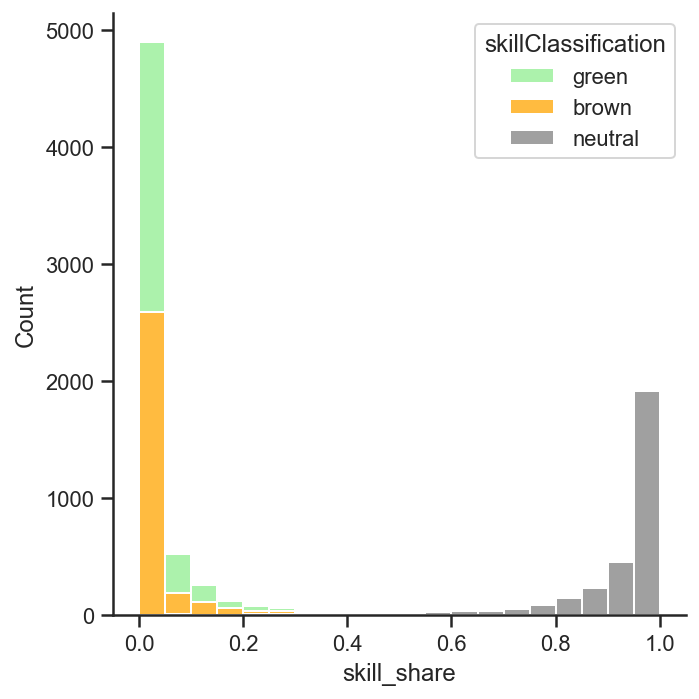

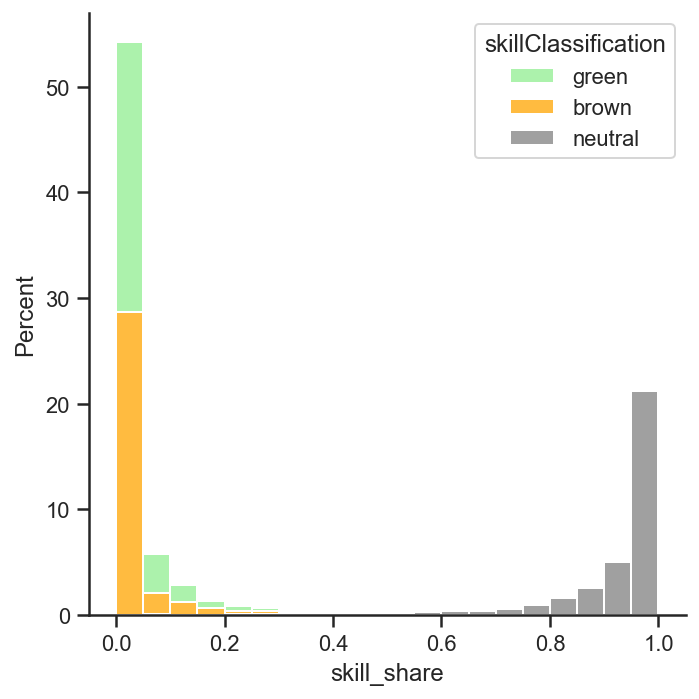

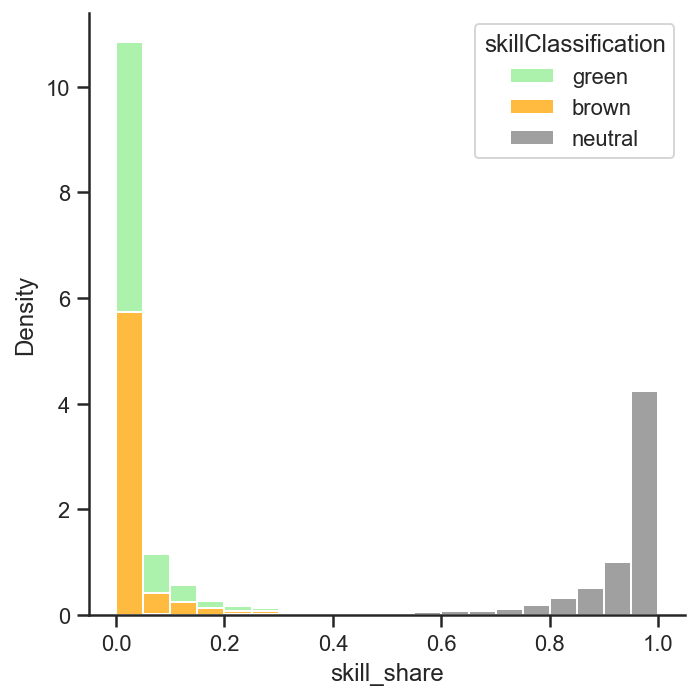

In [115]:
for stat in ["count", "percent", "density"]:
    f, ax = plt.subplots()

    sns.histplot(
        data=occ_data_long,
        # x="preferredLabel",
        x="skill_share",
        hue="skillClassification",
        multiple="stack",
        binwidth=0.05,
        stat=stat,
        hue_order=["green", "brown", "neutral"],
        palette=["lightgreen", "orange", "grey"],
        ax=ax
    )

    sns.despine()
    plt.tight_layout()

Plot occupations with highest g/b/n skill shares.

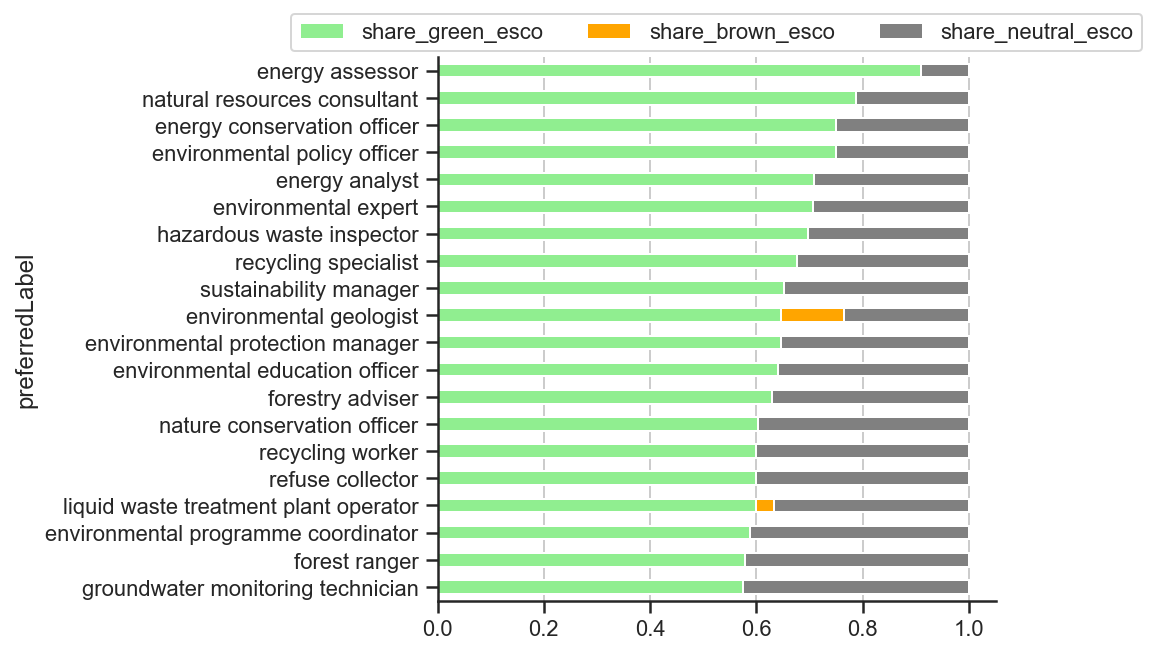

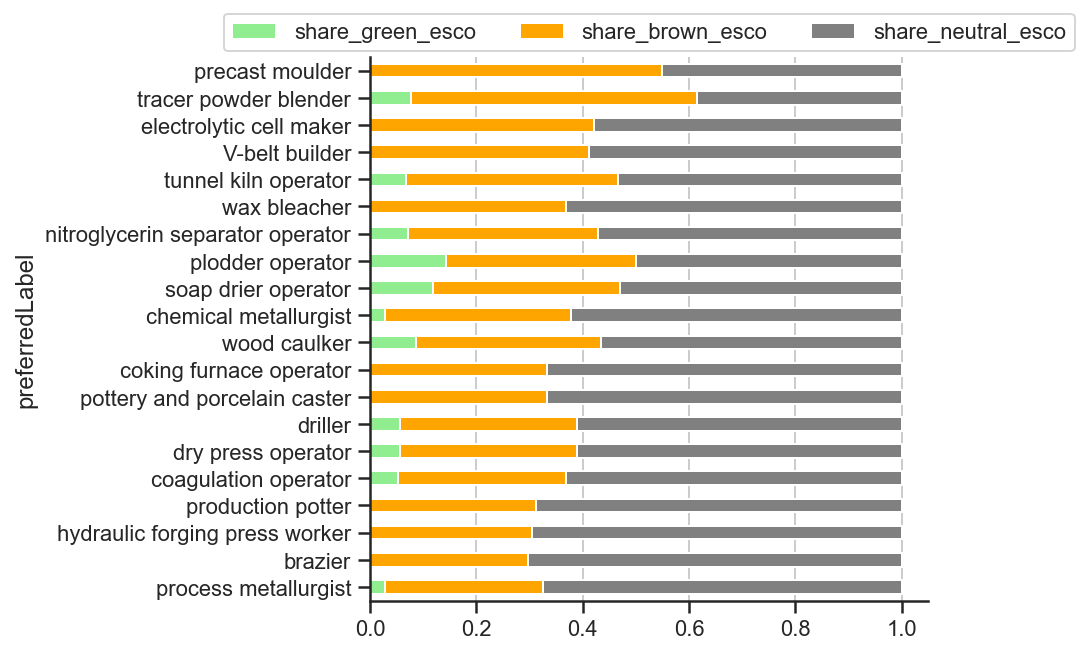

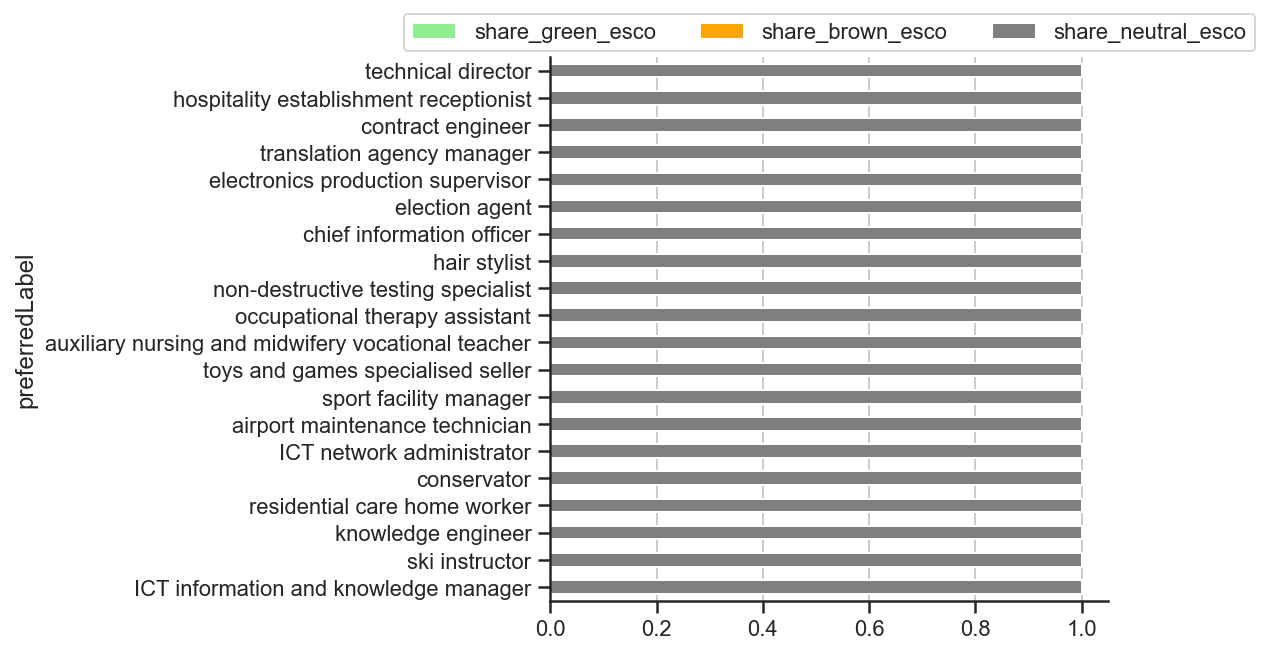

In [18]:
plotting_cols = ["share_green_esco", "share_brown_esco", "share_neutral_esco"]
n_highest = 20

for col in plotting_cols:
    occ_data_sub = (occ_data
                    .sort_values(col, ascending=False)
                    .loc[:, keep_cols]
                    .head(n_highest)[::-1])

    ax = occ_data_sub.plot.barh(
        stacked=True,
        x="preferredLabel",
        color=["lightgreen", "orange", "grey"]
    )

    ax.grid(axis="x", linestyle="-")
    plotting_utils.move_legend_to_top(ax, scale=1, ncol=3)
    sns.despine()

**Q: Which skills are mapped to the top-ranked occupations by GBN type?**

In [116]:
osm_weighted

conceptUri,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,http://data.europa.eu/esco/skill/00064735-8fad-454b-90c7-ed858cc993f2,http://data.europa.eu/esco/skill/000709ed-2be5-4193-b056-45a97698d828,http://data.europa.eu/esco/skill/0007bdc2-dd15-4824-b7d6-416522c46f35,http://data.europa.eu/esco/skill/00090cc1-1f27-439e-a4e0-19a87a501bfc,http://data.europa.eu/esco/skill/000bb1e4-89f0-4b86-be05-05ece3641724,http://data.europa.eu/esco/skill/000c94d2-2a2e-4545-993c-6df8cb5b0316,http://data.europa.eu/esco/skill/000f1d3d-220f-4789-9c0a-cc742521fb02,http://data.europa.eu/esco/skill/001115fb-569f-4ee6-8381-c6807ef2527f,http://data.europa.eu/esco/skill/001d46db-035e-4b92-83a3-ed8771e0c123,http://data.europa.eu/esco/skill/0023e7a5-43da-4b68-bee3-726ef21f986d,http://data.europa.eu/esco/skill/00298d97-3dc3-4086-a902-bce0a2fba831,http://data.europa.eu/esco/skill/002b2e58-35ab-460c-be97-ca2f585fd990,http://data.europa.eu/esco/skill/0037c821-2898-4919-b96e-7ed1cd89554c,http://data.europa.eu/esco/skill/004017c9-0337-4f5a-8077-798de9ef12e3,http://data.europa.eu/esco/skill/004f1e68-9ca2-4f3f-92d9-e7d7ff6b9330,http://data.europa.eu/esco/skill/00506f28-e884-4496-800c-3477c67eb355,http://data.europa.eu/esco/skill/0058526a-11e9-40a1-ab33-7c5ffdf5da05,http://data.europa.eu/esco/skill/00735755-adc6-4ea0-b034-b8caff339c9f,http://data.europa.eu/esco/skill/0082c13b-5866-4542-bc4f-722a4ae9530e,http://data.europa.eu/esco/skill/00831ebb-bac3-4bd1-8dae-2bca67be958d,http://data.europa.eu/esco/skill/0085e6bd-6829-4e8e-b302-842a7fe57ed9,http://data.europa.eu/esco/skill/008a0e0d-7380-4b31-abe5-0195e700f8c0,http://data.europa.eu/esco/skill/008fa98b-dba6-4abf-909e-04299728e3eb,http://data.europa.eu/esco/skill/00920055-eb50-4cb8-a23d-3deedbf3753e,http://data.europa.eu/esco/skill/009673d9-e2fd-46ef-a64b-6027ac7fd613,http://data.europa.eu/esco/skill/00994812-ac9e-4856-954b-f71bcc6066bb,http://data.europa.eu/esco/skill/009db49b-fcf5-4409-b4a5-232d059f3597,http://data.europa.eu/esco/skill/00a4e92d-e410-42b8-ba2d-d7b3febf49e0,http://data.europa.eu/esco/skill/00b9a3aa-7070-4bb5-8020-f228a97cf42f,http://data.europa.eu/esco/skill/00c04e40-35ea-4ed1-824c-82f936c8f876,http://data.europa.eu/esco/skill/00c51318-4ea9-4d37-9cd8-74680583d203,http://data.europa.eu/esco/skill/00c85cbc-2b24-4605-a6fe-55b5c615e3fe,http://data.europa.eu/esco/skill/00cd1d60-782f-48e7-9a7b-b518f2b146b8,http://data.europa.eu/esco/skill/00dd3271-077f-4a12-a958-e297fdd724ce,http://data.europa.eu/esco/skill/00e261cc-669c-4b94-8950-d038eceb92d8,http://data.europa.eu/esco/skill/00e53a0a-c0ba-4c9f-a2ed-4706d5832a00,http://data.europa.eu/esco/skill/00e895f4-b9d3-4a1a-8c36-baf10fbfb982,http://data.europa.eu/esco/skill/00eada7f-0b83-4f0c-af81-d7f92d838000,http://data.europa.eu/esco/skill/00ebb379-ce26-439a-ba89-9a7d1ef2f696,http://data.europa.eu/esco/skill/00ec5333-e570-477b-9017-2e95fea0150a,http://data.europa.eu/esco/skill/00eefa32-9f77-4500-abe9-20afc7924a9d,http://data.europa.eu/esco/skill/00f12ec1-b416-4e3c-8ed7-c4f875c6b681,http://data.europa.eu/esco/skill/00f2eee1-cd4d-4a45-ae10-b6060f53ad5d,http://data.europa.eu/esco/skill/00fc7575-0cee-4b12-ade5-795cb2a4479a,http://data.europa.eu/esco/skill/00ff06cc-103f-4c85-b5df-6f75acff6abf,http://data.europa.eu/esco/skill/011711eb-f20b-4d64-84d7-17b8979946dc,http://data.europa.eu/esco/skill/0121ac3b-775b-4faf-b86d-0078623674bc,http://data.europa.eu/esco/skill/01267c89-b27f-4de0-b555-3683c5a5d66e,http://data.europa.eu/esco/skill/012795fe-5f85-4d12-a10e-9dabda4ea05f,http://data.europa.eu/esco/skill/012d6406-016a-4790-aeb8-853e61058517,http://data.europa.eu/esco/skill/012f9ad1-b95b-42f1-b2c7-3793cdbce443,http://data.europa.eu/esco/skill/0132ac4f-ffac-4396-8b56-052fde0c9d73,http://data.europa.eu/esco/skill/013441c1-1f13-47e9-80c4-9a53e8e1bc05,http://data.europa.eu/esco/skill/0138fdc7-edbb-485c-9aa9-544f723eb62f,http://data.europa.eu/esco/skill/013a64b9-5e74-4f7f-af5b-9ec76715238b,http://data.europa.eu/esco/skill/01468114-b99c-4f48-9374-a520a7faa9c9

In [117]:
occ_data

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,id,concept_uri,preferred_label,onet_code,onet_occupation,n_total_specific_skills,n_green_specific_skills,share_green_esco,n_brown_specific_skills,share_brown_esco,n_neutral_specific_skills,share_neutral_esco,gbn_classification_esco,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,soc_code,occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2654,2,26,265,0.0,http://data.europa.eu/esco/occupation/00030d09...,technical director,27-1011.00,art directors,8,0,0.000000,0,0.000000,8,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,metal drawing machine technician\nmetal drawin...,NaN,released,2016-07-05T17:09:43Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,8121,8,81,812,1.0,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,51-4021.00,"extruding and drawing machine setters, operato...",39,0,0.000000,5,0.128205,34,0.871795,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51-4021.00,"Extruding and Drawing Machine Setters, Operato...",True,False,False,brown
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,inspector of precision instruments\nprecision ...,NaN,released,2016-07-06T09:21:20Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precision device inspectors make sure precisio...,7543.10.3,7543,7,75,754,2.0,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,51-9061.00,"inspectors, testers, sorters, samplers, and we...",43,0,0.000000,0,0.000000,43,1.000000,neutral,"Inspectors, Testers, Sorters, Samplers, and We...",Green Enhanced Skills,2.0,0.0,30.0,0.0625,"Inspectors, Testers, Sorters, Samplers, and We...",0.0625,32.0,2.0,NaN,NaN,False,True,False,green
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2017-01-17T11:40:37Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,3155,3,31,315,3.0,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,17-3023.01,electronics engineering technicians,39,2,0.051282,0,0.000000,37,0.948718,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,hospitality revenues manager\nyield manager\nh...,NaN,released,2017-01-17T13:33:42Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,2431,2,24,243,4.0,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,13-1161.00,market research analysts and marketing special...,26,0,0.000000,0,0.000000,26,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
...,...,...,...,...,...,...,...,...,...,...,